<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_06_CNN_Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - Face Mask Detection using CNN**

# **2. Problem Statement**
The goal of this project is to develop a deep learning model using Convolutional Neural
Networks (CNN) that can automatically detect whether a person in an image or video is
wearing a face mask or not.
This system can be used in real-world scenarios such as:
- Public places (airports, malls, hospitals)
- Surveillance systems
- Entry control systems for safety compliance

The model should take an input image (or video frame) and classify it into:
- With Mask
- Without Mask

# **3. Project Objectives**
- Understand image classification using deep learning
- Perform data preprocessing and augmentation
- Train and evaluate a CNN-based model

# **4. Data Understanding**

**a. Load Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


**b. Checking the main folder**

In [ ]:
import os
print(os.listdir(path))

['data']


**c. Print all sub directories**

In [ ]:
base_path = os.path.join(path,'data')
print(os.listdir(base_path))

['without_mask', 'with_mask']


**d. Display 5 images of each class**

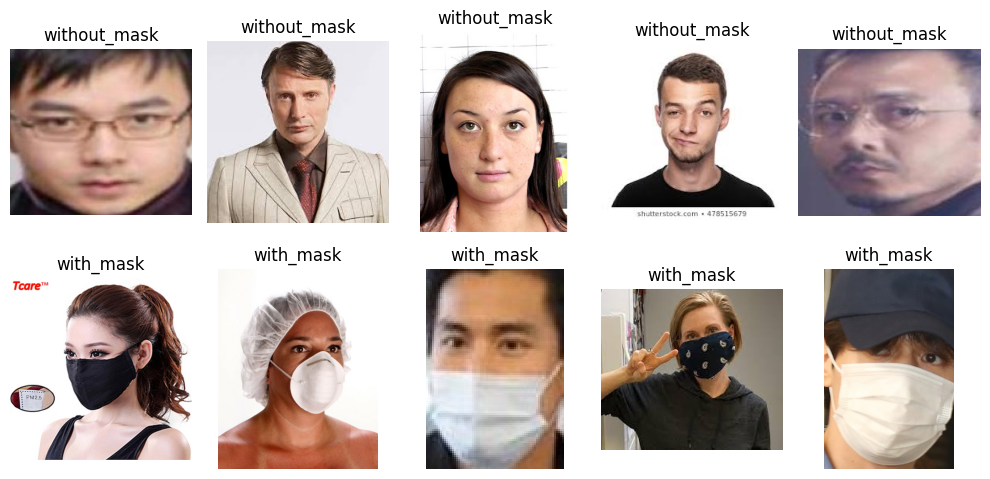

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base_path = os.path.join(path,'data')
plt.figure(figsize=(10,12))

i = 1
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      image_path = os.path.join(class_path,img)
      img = Image.open(image_path)

      plt.subplot(5,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')
      i+=1
plt.tight_layout()
plt.show()

In [ ]:
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,':',count)

without_mask : 3828
with_mask : 3725


**e. Create dataframe which includes imagepath and labels**

In [ ]:
import pandas as pd
data=[]
base_path = os.path.join(path,'data')
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      data.append([img_path,class_name])
df = pd.DataFrame(data,columns=['image_path','label'])

In [ ]:
df

,image_path,label
0,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
1,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
2,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
3,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
4,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
...,...,...
7548,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7549,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7550,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7551,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask


**f. Shuffle data**

In [ ]:
df = df.sample(frac=1,random_state=42).reset_index()

In [ ]:
df

,index,image_path,label
0,1153,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
1,393,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
2,742,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
3,2879,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
4,23,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
...,...,...,...
7548,5191,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7549,5226,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7550,5390,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7551,860,/kaggle/input/face-mask-dataset/data/without_m...,without_mask


**g. Find size of image**

In [ ]:
img = df['image_path'][0]
image = Image.open(img)
height,width = image.size
print(height,width)

267 189


# **5. Data preprocessing**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**a. Resize images**

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

**b. Normalization and Data Augmentation**

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **6. Split data for training,validation and testing**

In [ ]:
train_size = int(0.7* len(df))
test_size = int(0.15* len(df))
val_size = int(0.15* len(df))
print("train_size---->",train_size)
print("test_size---->",test_size)
print("val_size---->",val_size)

train_size----> 5287
test_size----> 1132
val_size----> 1132


In [ ]:
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:train_size+test_size]
val_data = df.iloc[train_size+test_size :]
print("train_data--->",len(train_data))
print("test_data--->",len(test_data))
print("val_data--->",len(val_data))

train_data---> 5287
test_data---> 1132
val_data---> 1134


In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 5287 validated image filenames belonging to 2 classes.


In [ ]:
# val data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 1134 validated image filenames belonging to 2 classes.


In [ ]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 1132 validated image filenames belonging to 2 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 166)
Train Label Shape: (32, 2)

Validation Shape: (32, 224, 224, 3) (Batches = 36)
Validation Label Shape: (32, 2)

Test Shape: (32, 224, 224, 3) (Batches = 36)
Test Label Shape: (32, 2)



# **7. Model Building**

In [ ]:
from tensorflow.keras import models,layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
n_classes=len(train_generator.class_indices)
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation = 'softmax')

])

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,266 (2.61 MB)

 Trainable params: 683,266 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer=Adam(),loss=categorical_crossentropy,
                  metrics=['accuracy'])

# **8. Model Training**

**a. Train the model on training data and Validate using validation dataset**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

cnn = cnn_model.fit(
    train_generator,
    epochs= 100,
    validation_data = val_generator,verbose=1
)

Epoch 1/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 94s 563ms/step - accuracy: 0.8337 - loss: 0.3916 - val_accuracy: 0.8439 - val_loss: 0.3660
Epoch 2/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 87s 523ms/step - accuracy: 0.8691 - loss: 0.3242 - val_accuracy: 0.8404 - val_loss: 0.3917
Epoch 3/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 87s 525ms/step - accuracy: 0.8793 - loss: 0.2970 - val_accuracy: 0.8598 - val_loss: 0.3230
Epoch 4/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 87s 527ms/step - accuracy: 0.8880 - loss: 0.2757 - val_accuracy: 0.9109 - val_loss: 0.2683
Epoch 5/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 87s 522ms/step - accuracy: 0.8933 - loss: 0.2678 - val_accuracy: 0.9065 - val_loss: 0.2626
Epoch 6/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 86s 518ms/step - accuracy: 0.8982 - loss: 0.2554 - val_accuracy: 0.9189 - val_loss: 0.2331
Epoch 7/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 87s 524ms/step - accuracy: 0.9073 - loss: 0.2450 - val_accuracy: 0.9048 - val_loss: 0.2562
Epoch 8/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 89s 534ms/step - accuracy: 0.9102 -

**b. Test the overall model performance**

In [ ]:
# Evaluate on the training data
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

166/166 ━━━━━━━━━━━━━━━━━━━━ 67s 404ms/step - accuracy: 0.9866 - loss: 0.0426
Training accuracy: 0.9866
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 487ms/step - accuracy: 0.9744 - loss: 0.0924
Test accuracy: 0.9744


**c. Face Mask Classification**

Saving with_mask_977.jpg to with_mask_977.jpg
Saving without_mask_997.jpg to without_mask_997.jpg
Class indices used by the model: {'with_mask': 0, 'without_mask': 1}
Ordered class names for prediction: ['with_mask', 'without_mask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step


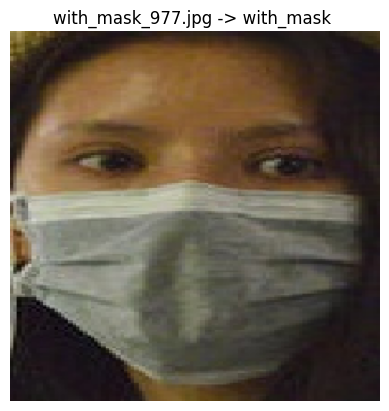

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


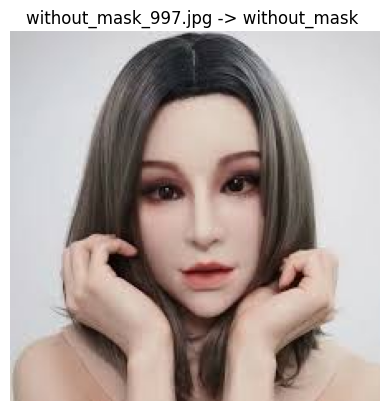

In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Upload multiple images
uploaded = files.upload()

# Get class labels from the generator
class_labels_map = {v: k for k, v in train_generator.class_indices.items()}
class_names = [class_labels_map[i] for i in range(len(class_labels_map))]

print("Class indices used by the model:", train_generator.class_indices)
print("Ordered class names for prediction:", class_names)

# Loop through all uploaded images
for img_path in uploaded.keys():

    # Load & preprocess
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = cnn_model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class = class_names[predicted_class_index]
    confidence = prediction[0][predicted_class_index] * 100

    # Show result
    plt.imshow(img)
    plt.title(f"{img_path} -> {predicted_class} ")
    plt.axis("off")
    plt.show()

# **9. Model Evaluation**

**a. Accuracy**

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 388ms/step - accuracy: 0.9673 - loss: 0.1041
Test Accuracy: 0.9673144817352295


**b. Confusion Matrix**

In [ ]:
import numpy as np
predictions = cnn_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 390ms/step


In [ ]:
y_true = test_generator.classes

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

array([[266, 273],
       [278, 315]])

**c. Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.49      0.49       539
           1       0.54      0.53      0.53       593

    accuracy                           0.51      1132
   macro avg       0.51      0.51      0.51      1132
weighted avg       0.51      0.51      0.51      1132

